In [2]:
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, classification_report, matthews_corrcoef

# Modelos (mismos que en el entorno tfm)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

RANDOM_STATE = 42
OUTPUT_DIR   = "resultados_shap"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# Carga del CSV de descriptores generado en el entorno tfm (paso 4)
df_desc_full = pd.read_csv('paso4_descriptores_mordred.csv')

# Separar IDs, etiquetas y descriptores
chembl_ids = df_desc_full['ChEMBL_ID'].values
y          = df_desc_full['Label'].values
X_full     = df_desc_full.drop(columns=['ChEMBL_ID', 'Label'])

print(f"Compuestos: {len(y)}")
print(f"Descriptores: {X_full.shape[1]}")
print(f"Activos: {y.sum()} ({y.mean():.1%}) | Inactivos: {(y==0).sum()}")

Compuestos: 55
Descriptores: 1219
Activos: 16 (29.1%) | Inactivos: 39


In [4]:
def correlation_filter(X: pd.DataFrame, threshold: float, method: str = 'pearson') -> list:
    """Misma función que en el entorno tfm (paso 5)."""
    corr_matrix = X.corr(method=method).abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop  = {col for col in upper.columns if any(upper[col] >= threshold)}
    retained = [col for col in X.columns if col not in to_drop]
    return retained

CORR_THRESHOLDS = [0.7, 0.8, 0.9]
feature_sets = {}

for thr in CORR_THRESHOLDS:
    for method in ['pearson', 'spearman']:
        key      = f'{method}_thr{thr}'
        retained = correlation_filter(X_full, thr, method)
        feature_sets[key] = retained
        print(f'  {key:30s} → {len(retained):4d} descriptores')

feature_sets['no_filter'] = list(X_full.columns)
print(f"  {'no_filter':30s} → {len(X_full.columns):4d} descriptores")

  pearson_thr0.7                 →   74 descriptores
  spearman_thr0.7                →   90 descriptores
  pearson_thr0.8                 →  175 descriptores
  spearman_thr0.8                →  200 descriptores
  pearson_thr0.9                 →  356 descriptores
  spearman_thr0.9                →  377 descriptores
  no_filter                      → 1219 descriptores


In [5]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE   # ← mismo random_state que en paso 6
)
print(f"Train: {len(y_train)} | Test: {len(y_test)}")

Train: 44 | Test: 11


In [7]:
TOP6_MODELS = [
    (
        "AdaBoost",'pearson_thr0.7',
        AdaBoostClassifier(random_state=42),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    (
        'LogisticRegression', 'pearson_thr0.7',
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {'clf__C': [ 0.1],
         'clf__solver': ['lbfgs'],
         'clf__penalty': ['l2']}
    ),
    (
        "ExtraTrees",'pearson_thr0.7',
        ExtraTreesClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    (
        "XGBoost",'spearman_thr0.7',
        XGBClassifier(random_state=42, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),
    (
        "AdaBoost",'spearman_thr0.7',
        AdaBoostClassifier(random_state=42),
        {
            "clf__n_estimators" : [50],
            "clf__learning_rate": [ 1.0],
        }
    ),
    (
        "RandomForest", 'spearman_thr0.7',
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"    : ["sqrt", "log2"],
        }
    ),
]
# ─────────────────────────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_estimators = {}

for model_name, fs_name, estimator, param_grid in TOP6_MODELS:
    key    = f'{model_name}__{fs_name}'
    fs_cols = feature_sets[fs_name]
    X_tr   = X_train_full[fs_cols]

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     estimator),
    ])

    gs = GridSearchCV(pipe, param_grid, cv=cv,
                      scoring='roc_auc', n_jobs=-1, refit=True)
    gs.fit(X_tr, y_train)
    best_estimators[key] = gs.best_estimator_

    y_prob = gs.best_estimator_.predict_proba(X_test_full[fs_cols])[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    print(f'  {key}: CV AUC={gs.best_score_:.3f} | Test AUC={auc:.3f}')
    print(f'  Mejores parámetros: {gs.best_params_}')

  AdaBoost__pearson_thr0.7: CV AUC=1.000 | Test AUC=1.000
  Mejores parámetros: {'clf__learning_rate': 0.5, 'clf__n_estimators': 50}
  LogisticRegression__pearson_thr0.7: CV AUC=1.000 | Test AUC=1.000
  Mejores parámetros: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  ExtraTrees__pearson_thr0.7: CV AUC=1.000 | Test AUC=1.000
  Mejores parámetros: {'clf__max_depth': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
  XGBoost__spearman_thr0.7: CV AUC=1.000 | Test AUC=1.000
  Mejores parámetros: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
  AdaBoost__spearman_thr0.7: CV AUC=1.000 | Test AUC=0.958
  Mejores parámetros: {'clf__learning_rate': 1.0, 'clf__n_estimators': 50}
  RandomForest__spearman_thr0.7: CV AUC=1.000 | Test AUC=1.000
  Mejores parámetros: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 100}



── #1: AdaBoost (pearson_thr0.7) ──
Calculando permutation importance...


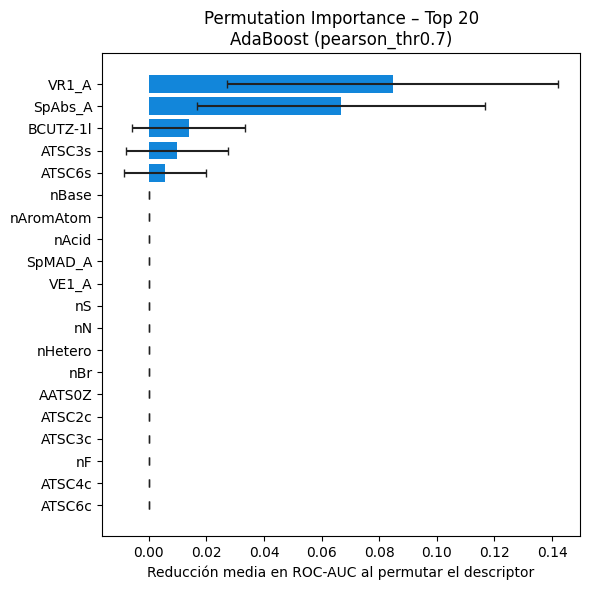

Top 5 descriptores:
     feature  importance_mean  importance_std
5      VR1_A         0.084722        0.057417
2    SpAbs_A         0.066667        0.050000
47  BCUTZ-1l         0.013889        0.019642
24    ATSC3s         0.009722        0.017623
26    ATSC6s         0.005556        0.014164

── #2: LogisticRegression (pearson_thr0.7) ──
Calculando permutation importance...


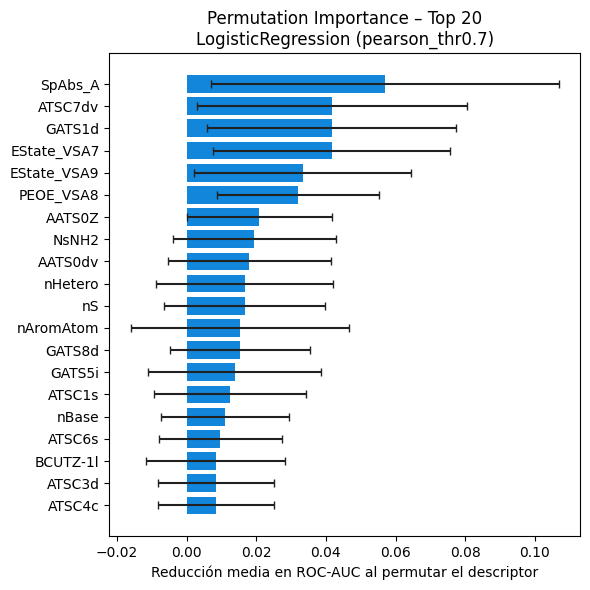

Top 5 descriptores:
        feature  importance_mean  importance_std
2       SpAbs_A         0.056944        0.049865
20      ATSC7dv         0.041667        0.038790
41       GATS1d         0.041667        0.035681
64  EState_VSA7         0.041667        0.034021
65  EState_VSA9         0.033333        0.031180

── #3: ExtraTrees (pearson_thr0.7) ──
Calculando permutation importance...


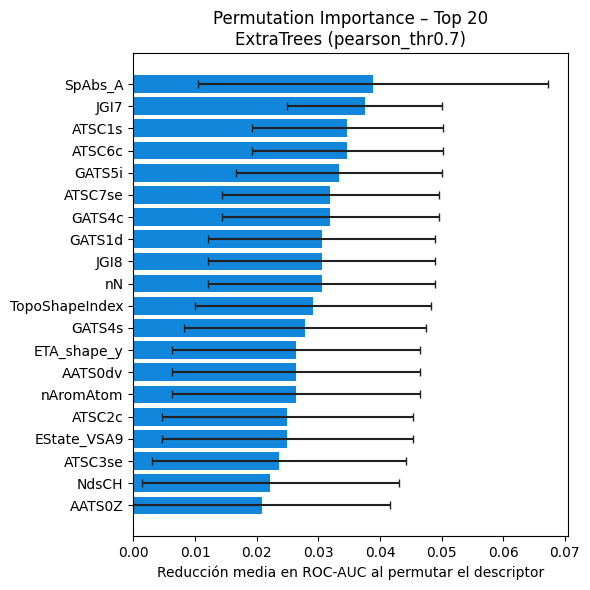

Top 5 descriptores:
    feature  importance_mean  importance_std
2   SpAbs_A         0.038889        0.028328
70     JGI7         0.037500        0.012500
23   ATSC1s         0.034722        0.015528
18   ATSC6c         0.034722        0.015528
45   GATS5i         0.033333        0.016667

── #4: XGBoost (spearman_thr0.7) ──
Calculando permutation importance...


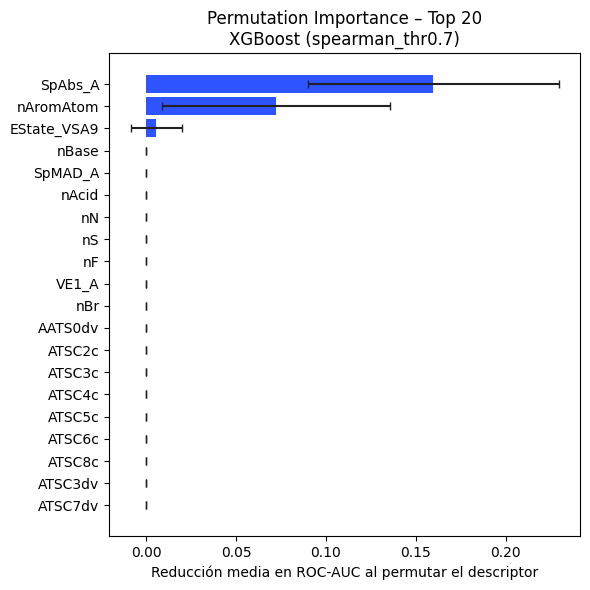

Top 5 descriptores:
        feature  importance_mean  importance_std
2       SpAbs_A         0.159722        0.069791
5     nAromAtom         0.072222        0.063586
81  EState_VSA9         0.005556        0.014164
1         nBase         0.000000        0.000000
3       SpMAD_A         0.000000        0.000000

── #5: AdaBoost (spearman_thr0.7) ──
Calculando permutation importance...


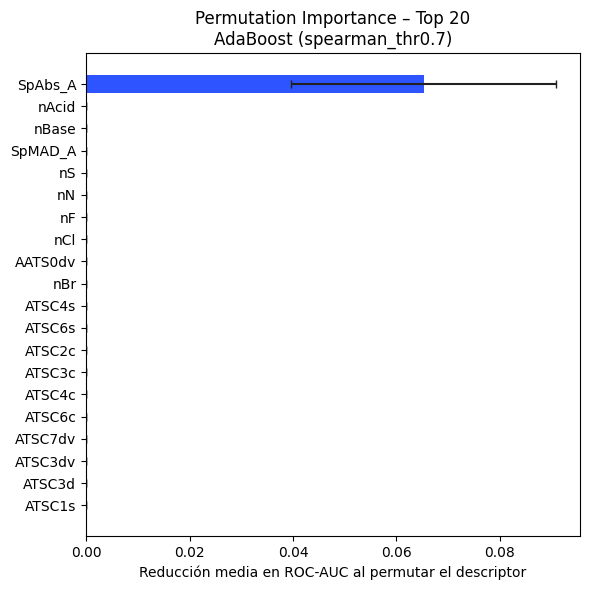

Top 5 descriptores:
   feature  importance_mean  importance_std
2  SpAbs_A         0.065278        0.025647
0    nAcid         0.000000        0.000000
1    nBase         0.000000        0.000000
3  SpMAD_A         0.000000        0.000000
7       nS         0.000000        0.000000

── #6: RandomForest (spearman_thr0.7) ──
Calculando permutation importance...


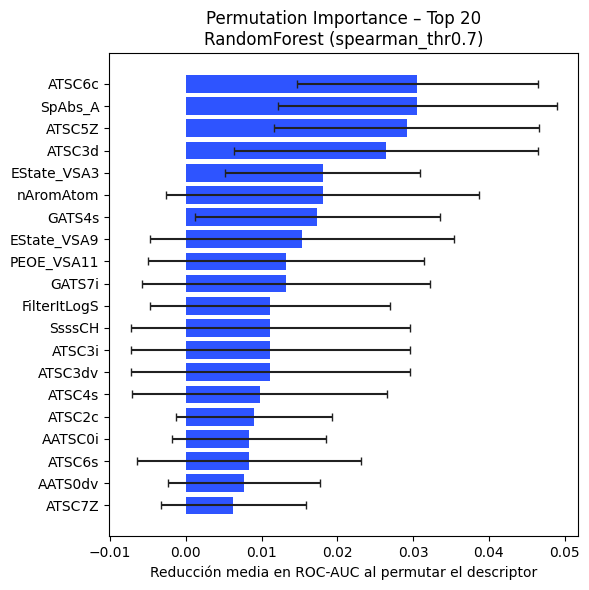

Top 5 descriptores:
        feature  importance_mean  importance_std
16       ATSC6c         0.030556        0.015897
2       SpAbs_A         0.030556        0.018426
28       ATSC5Z         0.029167        0.017513
20       ATSC3d         0.026389        0.020079
79  EState_VSA3         0.018056        0.012880


In [8]:
for rank, (model_name, fs_name, _, _) in enumerate(TOP6_MODELS, start=1):
    key     = f'{model_name}__{fs_name}'
    est     = best_estimators[key]
    fs_cols = feature_sets[fs_name]
    X_te_fs = X_test_full[fs_cols]

    print(f'\n── #{rank}: {model_name} ({fs_name}) ──')
    print('Calculando permutation importance...')

    perm = permutation_importance(
        est, X_te_fs, y_test,
        n_repeats=30,
        random_state=RANDOM_STATE,
        scoring='roc_auc',
        n_jobs=-1,
    )

    perm_df = pd.DataFrame({
        'feature'         : fs_cols,
        'importance_mean' : perm.importances_mean,
        'importance_std'  : perm.importances_std,
    }).sort_values('importance_mean', ascending=False)

    perm_df.to_csv(f'{OUTPUT_DIR}/permutation_importance_{rank}_{model_name}.csv',
                  index=False)
    
    if 'pearson' in fs_name.lower():
        color_grafico = "#1286DA"       # Azul Marino
    elif 'spearman' in fs_name.lower():
        color_grafico = '#2E54FF'    # Celeste
    else:
        color_grafico = '#4C72B0'

    # Gráfico top 20
    top20 = perm_df.head(20)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.barh(top20['feature'][::-1], top20['importance_mean'][::-1],
            xerr=top20['importance_std'][::-1],
            color=color_grafico, ecolor='#212121', capsize=3)
    ax.set_title(f'Permutation Importance – Top 20\n{model_name} ({fs_name})')
    ax.set_xlabel('Reducción media en ROC-AUC al permutar el descriptor')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/permutation_{rank}_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Top 5 descriptores:')
    print(perm_df.head())

## 6. SHAP – Análisis de interpretabilidad

- **TreeExplainer**: exacto y rápido para modelos basados en árboles (RF, GBM, XGB, ET)
- **LinearExplainer**: exacto para modelos lineales (LogisticRegression, SVM lineal)
- **KernelExplainer**: model-agnostic, funciona para cualquier modelo (más lento)


══ SHAP #1: AdaBoost (pearson_thr0.7) ══
  Usando KernelExplainer (puede tardar varios minutos)...


100%|██████████| 11/11 [00:08<00:00,  1.28it/s]


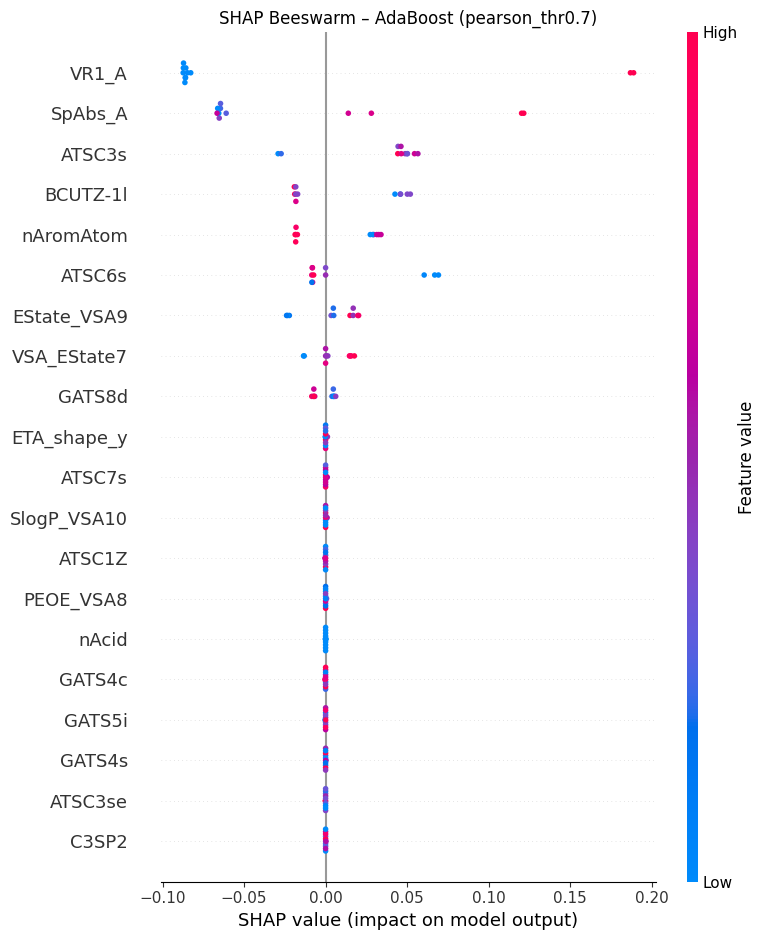

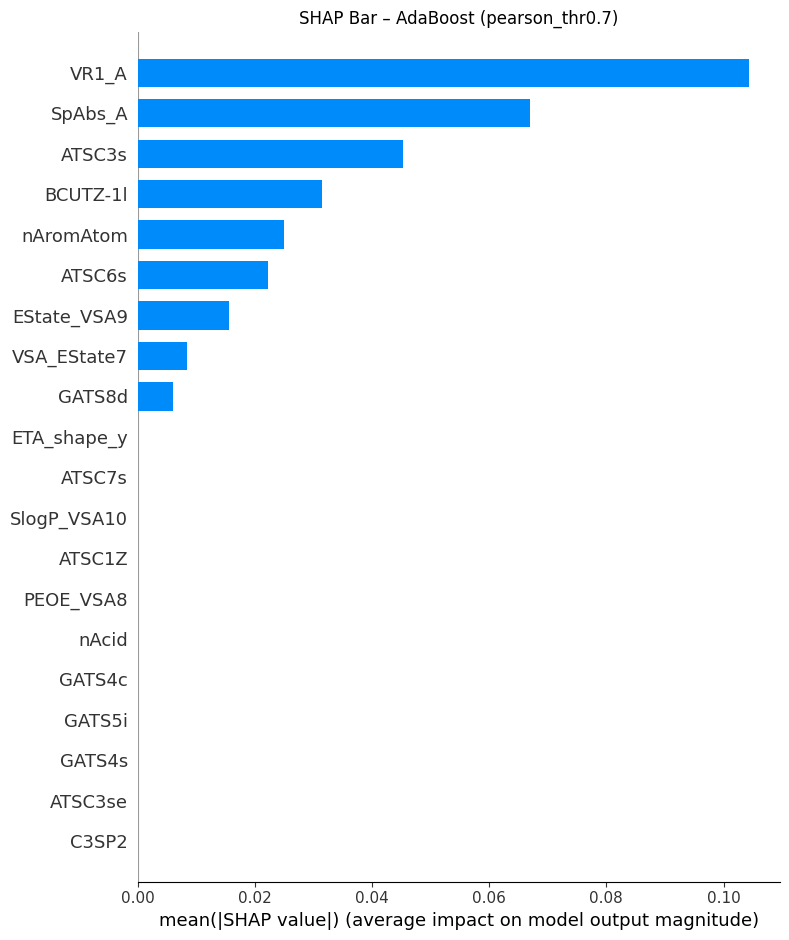

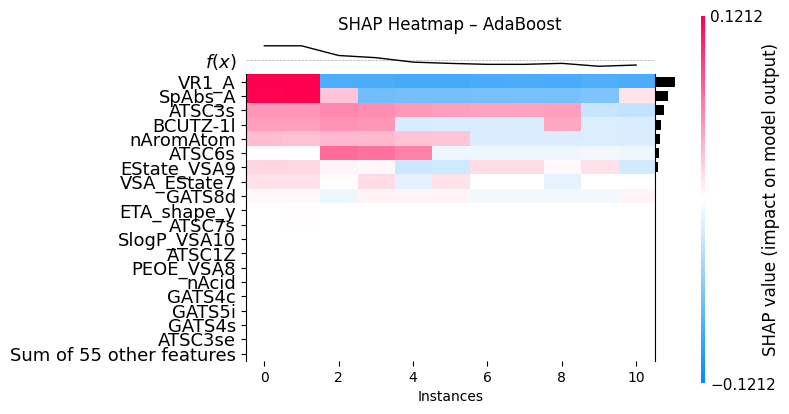


  Top 10 descriptores más influyentes (AdaBoost):
 descriptor  mean_abs_shap
      VR1_A       0.104423
    SpAbs_A       0.066991
     ATSC3s       0.045238
   BCUTZ-1l       0.031494
  nAromAtom       0.024952
     ATSC6s       0.022271
EState_VSA9       0.015586
VSA_EState7       0.008328
     GATS8d       0.006089
ETA_shape_y       0.000123

══ SHAP #2: LogisticRegression (pearson_thr0.7) ══
  Usando LinearExplainer...


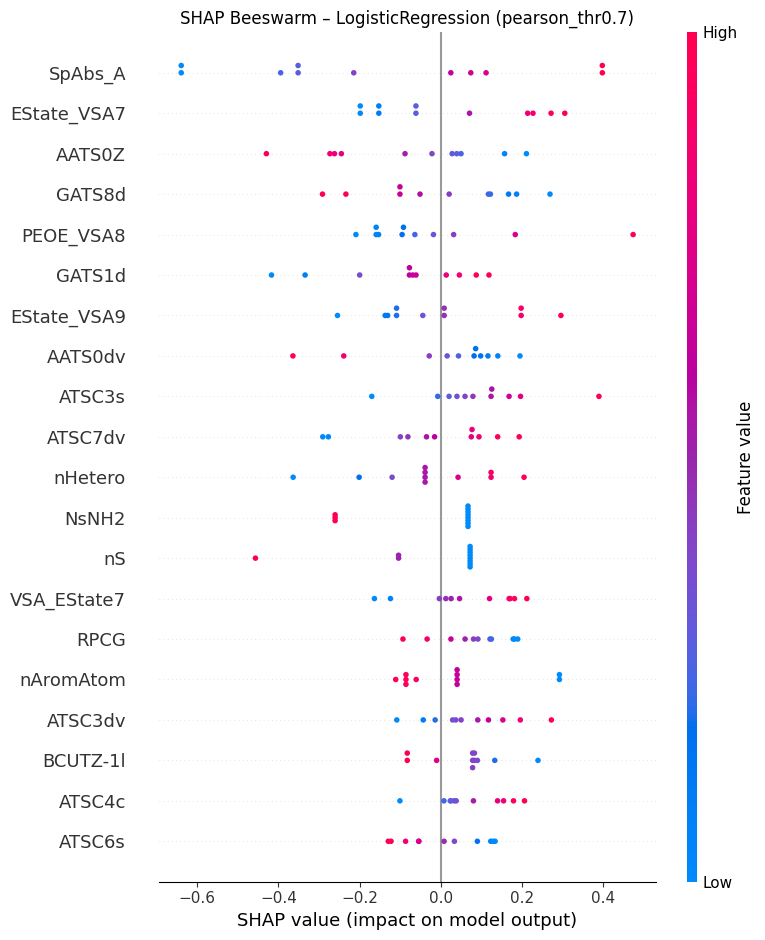

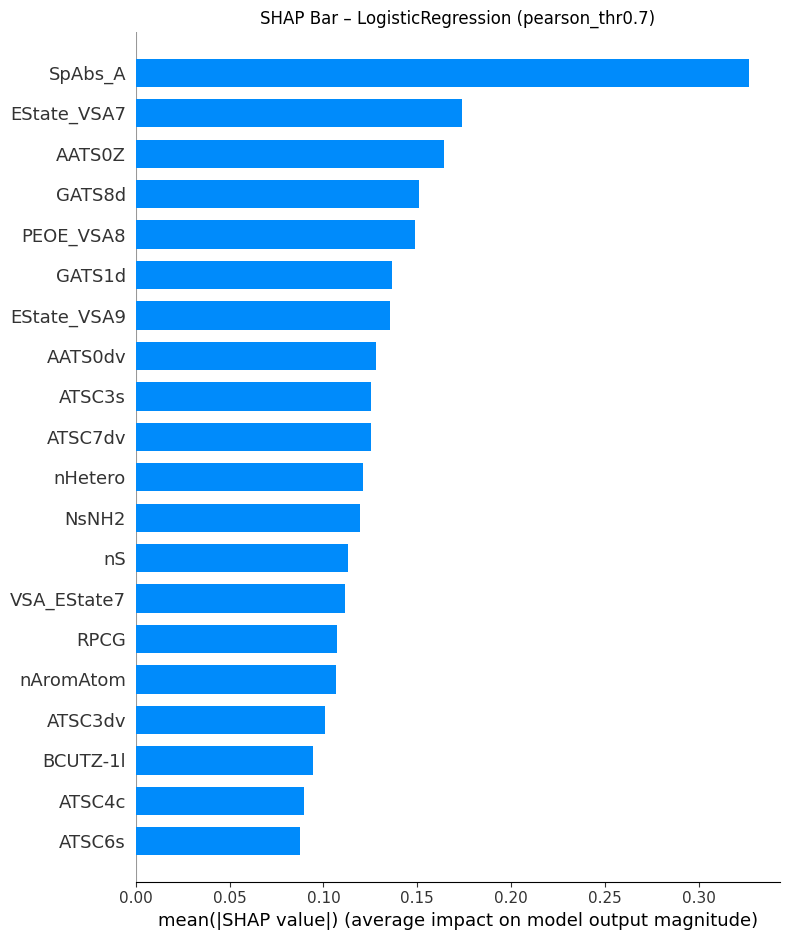

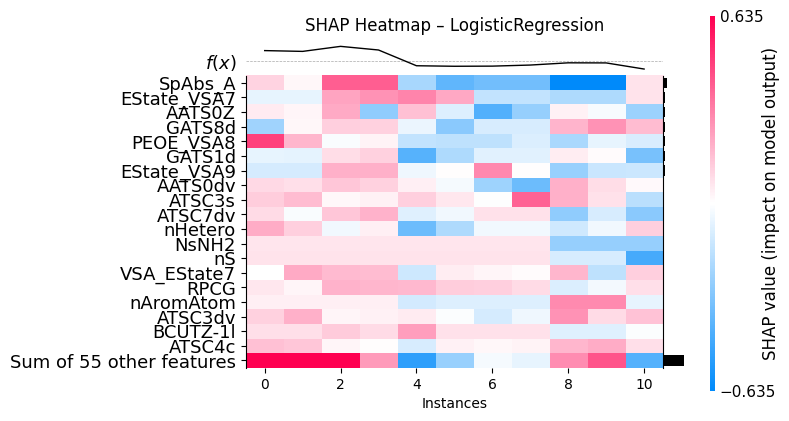


  Top 10 descriptores más influyentes (LogisticRegression):
 descriptor  mean_abs_shap
    SpAbs_A       0.326910
EState_VSA7       0.173929
     AATS0Z       0.164041
     GATS8d       0.150897
  PEOE_VSA8       0.148981
     GATS1d       0.136449
EState_VSA9       0.135737
    AATS0dv       0.128010
     ATSC3s       0.125378
    ATSC7dv       0.125266

══ SHAP #3: ExtraTrees (pearson_thr0.7) ══
  Usando TreeExplainer...


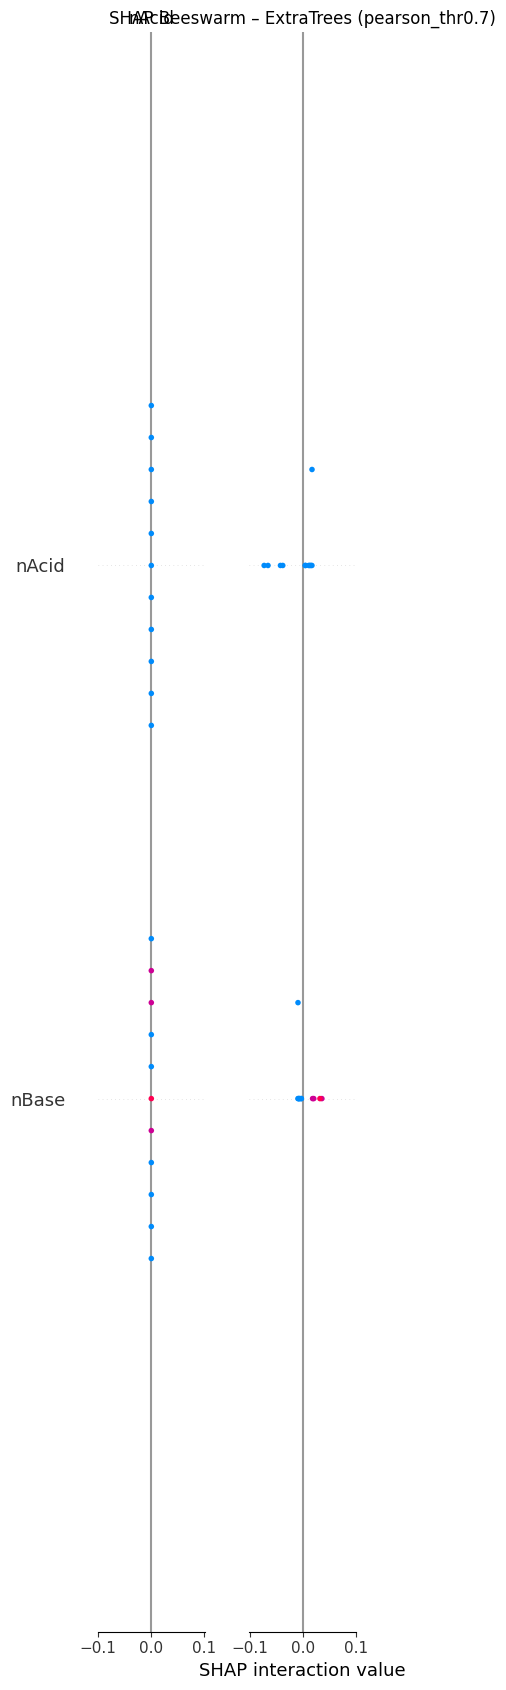

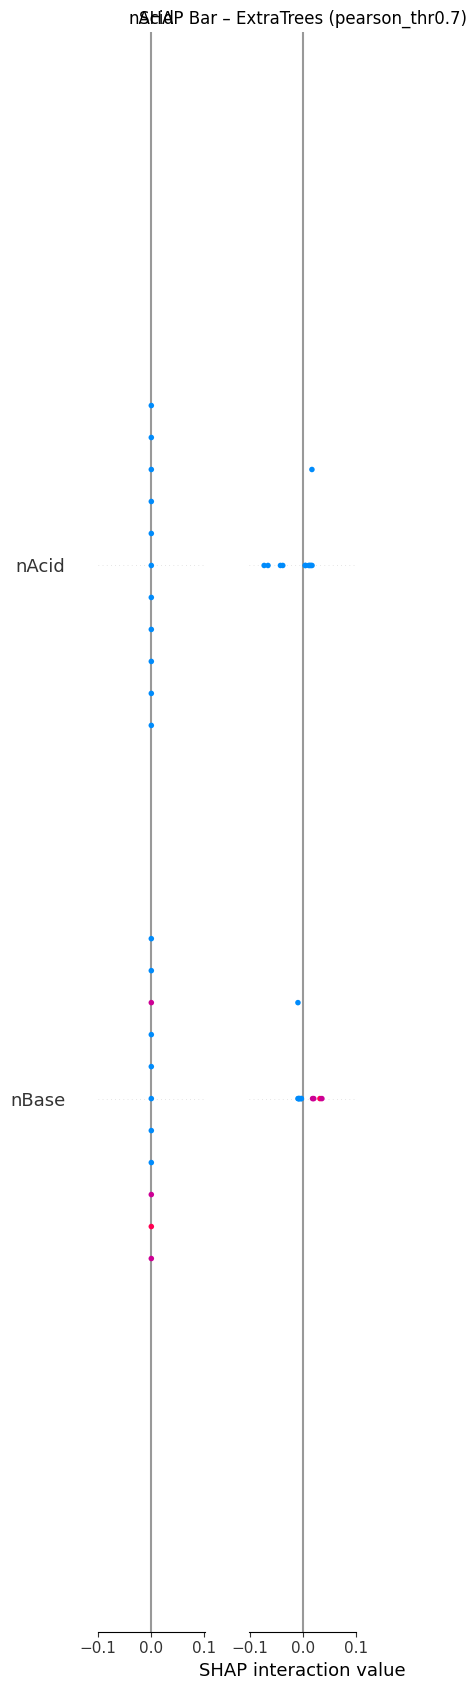

  ⚠️ Error en SHAP para ExtraTrees: could not broadcast input array from shape (2,) into shape (11,)

══ SHAP #4: XGBoost (spearman_thr0.7) ══
  Usando TreeExplainer...


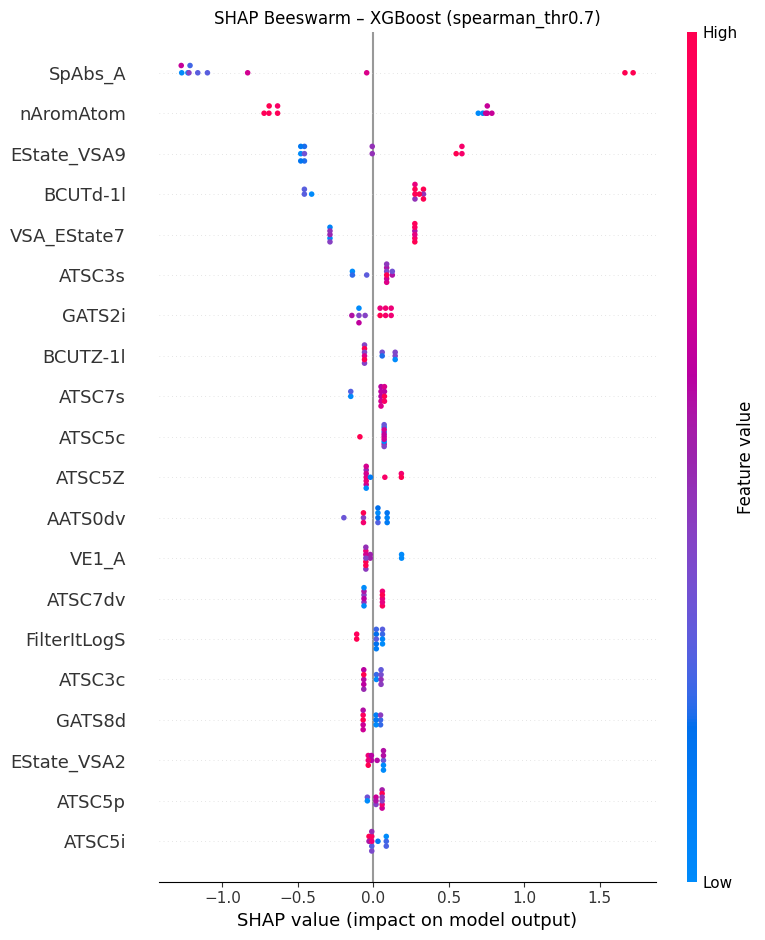

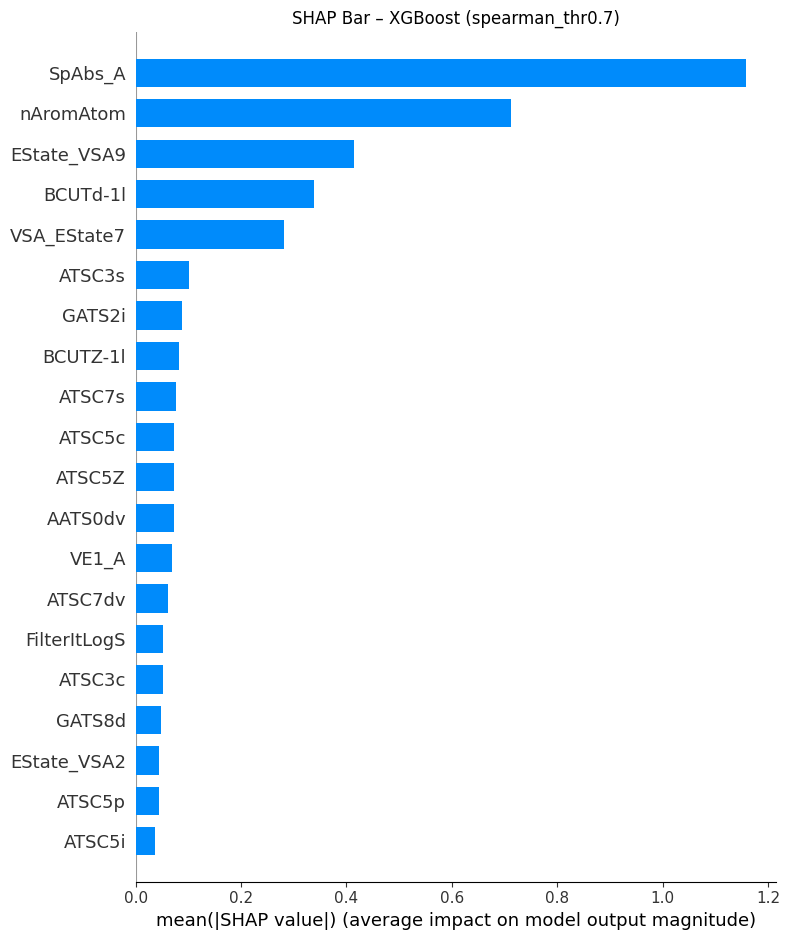

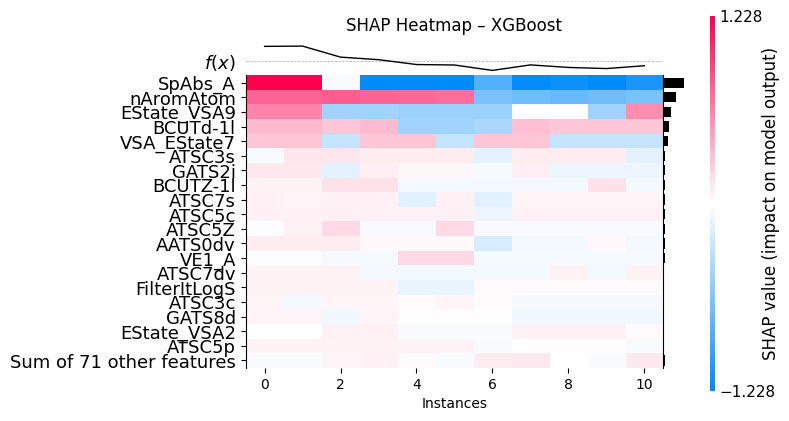


  Top 10 descriptores más influyentes (XGBoost):
 descriptor  mean_abs_shap
    SpAbs_A       1.158240
  nAromAtom       0.712757
EState_VSA9       0.413674
   BCUTd-1l       0.339187
VSA_EState7       0.280727
     ATSC3s       0.100455
     GATS2i       0.088344
   BCUTZ-1l       0.082103
     ATSC7s       0.077383
     ATSC5c       0.073576

══ SHAP #5: AdaBoost (spearman_thr0.7) ══
  Usando KernelExplainer (puede tardar varios minutos)...


100%|██████████| 11/11 [00:09<00:00,  1.21it/s]


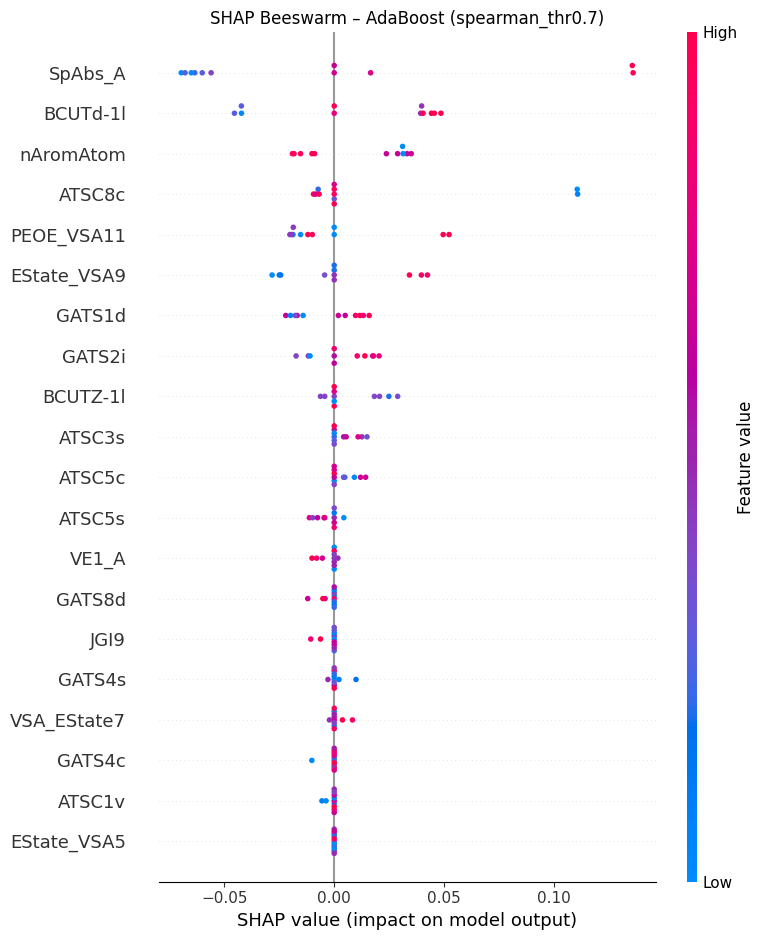

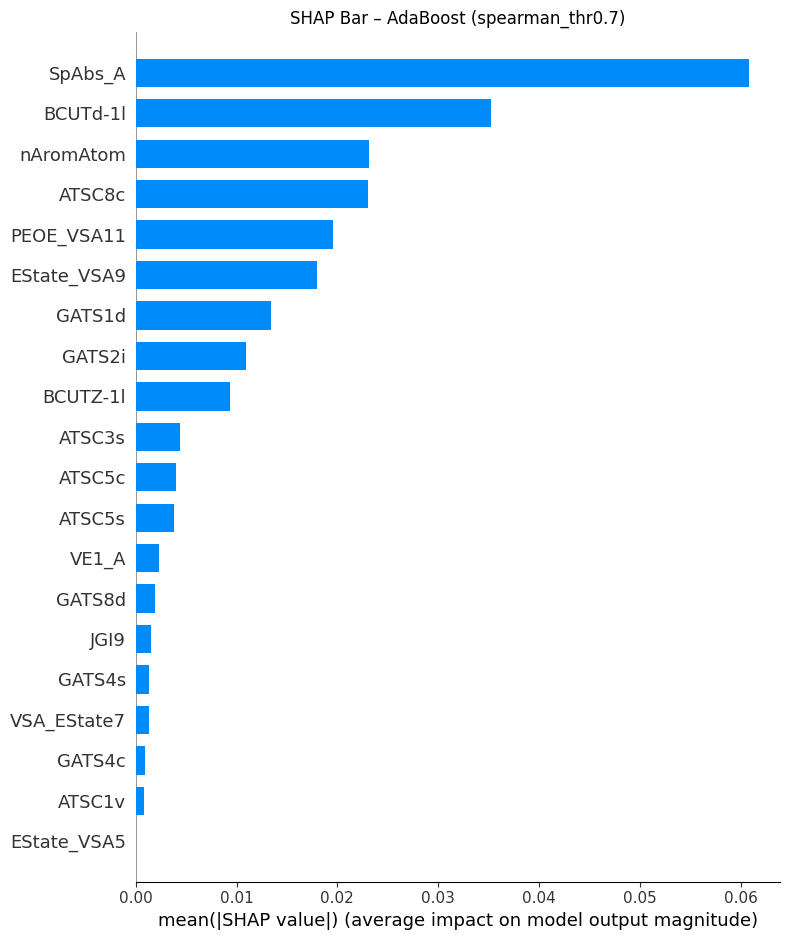

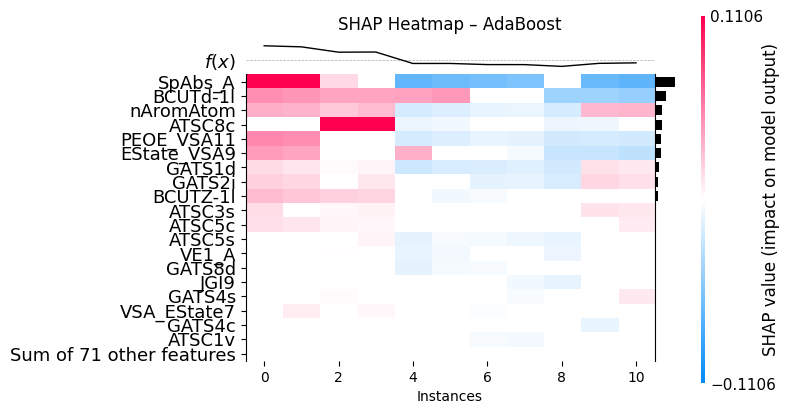


  Top 10 descriptores más influyentes (AdaBoost):
 descriptor  mean_abs_shap
    SpAbs_A       0.060868
   BCUTd-1l       0.035212
  nAromAtom       0.023148
     ATSC8c       0.023011
 PEOE_VSA11       0.019612
EState_VSA9       0.018009
     GATS1d       0.013444
     GATS2i       0.010926
   BCUTZ-1l       0.009375
     ATSC3s       0.004367

══ SHAP #6: RandomForest (spearman_thr0.7) ══
  Usando TreeExplainer...


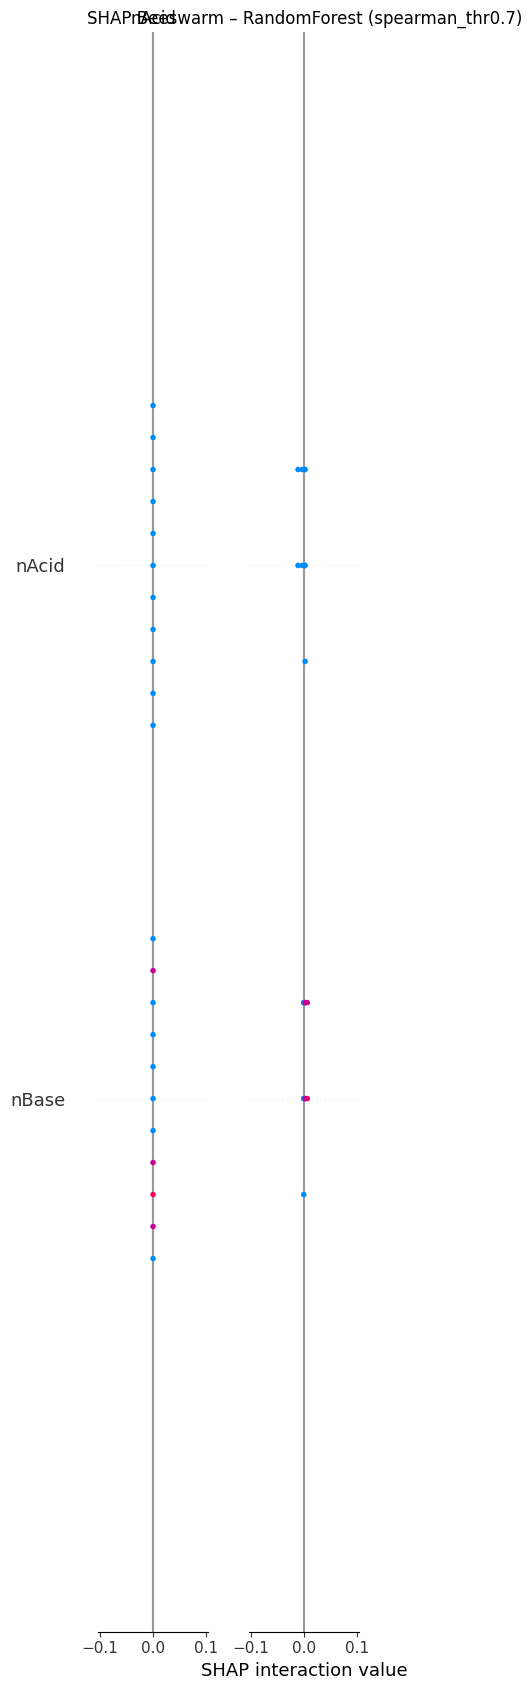

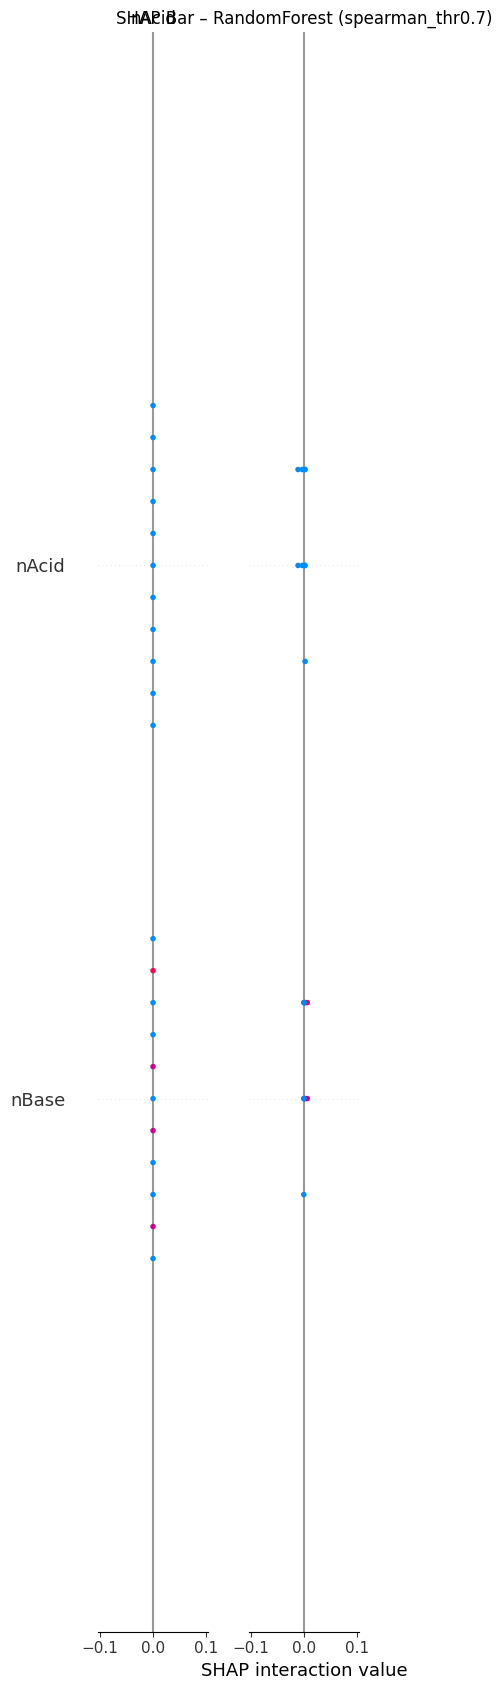

  ⚠️ Error en SHAP para RandomForest: could not broadcast input array from shape (2,) into shape (11,)


In [9]:
# Tipos de modelos basados en árboles
TREE_TYPES = (RandomForestClassifier, ExtraTreesClassifier,
              GradientBoostingClassifier, DecisionTreeClassifier)
if HAS_XGB: TREE_TYPES = TREE_TYPES + (XGBClassifier,)
if HAS_LGB: TREE_TYPES = TREE_TYPES + (LGBMClassifier,)

# Tipos de modelos lineales
LINEAR_TYPES = (LogisticRegression, SGDClassifier)


for rank, (model_name, fs_name, _, _) in enumerate(TOP6_MODELS, start=1):
    key     = f'{model_name}__{fs_name}'
    est     = best_estimators[key]
    fs_cols = feature_sets[fs_name]
    clf_step = est.named_steps['clf']

    print(f'\n══ SHAP #{rank}: {model_name} ({fs_name}) ══')

    # Transformar X_test con los pasos previos al clasificador (imputer + scaler)
    X_te_transformed = est[:-1].transform(X_test_full[fs_cols])
    X_te_df = pd.DataFrame(X_te_transformed, columns=fs_cols)

    # También transformar X_train para usar como background en KernelExplainer
    X_tr_transformed = est[:-1].transform(X_train_full[fs_cols])
    X_tr_df = pd.DataFrame(X_tr_transformed, columns=fs_cols)

    try:
        # ── Selección del explainer ────────────────────────────────────────────
        if isinstance(clf_step, TREE_TYPES):
            print('  Usando TreeExplainer...')
            explainer = shap.TreeExplainer(clf_step)
            shap_vals = explainer.shap_values(X_te_df)
            sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
            expected_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

        elif isinstance(clf_step, LINEAR_TYPES):
            print('  Usando LinearExplainer...')
            # Masker basado en los datos de entrenamiento (media + covarianza)
            masker    = shap.maskers.Independent(X_tr_df, max_samples=200)
            explainer = shap.LinearExplainer(clf_step, masker)
            shap_vals = explainer.shap_values(X_te_df)
            sv=shap_vals
            expected_val = explainer.expected_value

        else:
            # SVM RBF, KNN, MLP → KernelExplainer (más lento)
            print('  Usando KernelExplainer (puede tardar varios minutos)...')
            # Resumir el background con k-means para acelerar
            predict_fn = lambda x: clf_step.predict_proba(x)[:,1]
            background = shap.kmeans(X_tr_df, 30)
            #predict_fn = (clf_step.predict_proba
                          #if hasattr(clf_step, 'predict_proba')
                          #else clf_step.predict)
            # Usar solo una muestra del test para no tardar demasiado
            X_te_df   = X_te_df.reset_index(drop=True)
            explainer = shap.KernelExplainer(predict_fn, background)
            shap_vals = explainer.shap_values(X_te_df, silent=False)
            sv = shap_vals
            expected_val = explainer.expected_value

        # Para clasificación binaria: tomar clase positiva (activo)
        #sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

        # ── Plot 1: Beeswarm (distribución + dirección del efecto) ─────────────
        shap.summary_plot(sv, X_te_df, show=False, max_display=20, plot_type='dot')
        plt.title(f'SHAP Beeswarm – {model_name} ({fs_name})', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_beeswarm_{rank}_{model_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Plot 2: Bar (importancia media |SHAP|) ─────────────────────────────
        shap.summary_plot(sv, X_te_df, show=False, max_display=20, plot_type='bar')
        plt.title(f'SHAP Bar – {model_name} ({fs_name})', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_bar_{rank}_{model_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Plot 3: Heatmap SHAP (patrón global por compuesto) ─────────────────
        # Muestra qué descriptores dominan en cada compuesto individualmente
        shap_exp = shap.Explanation(
            values=sv,
            base_values=np.full(len(sv), explainer.expected_value
                                if not isinstance(explainer.expected_value, list)
                                else explainer.expected_value[1]),
            data=X_te_df.values,
            feature_names=fs_cols
        )
        shap.plots.heatmap(shap_exp, max_display=20, show=False)
        plt.title(f'SHAP Heatmap – {model_name}', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_heatmap_{rank}_{model_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Guardar SHAP values como CSV ───────────────────────────────────────
        shap_df = pd.DataFrame(sv, columns=fs_cols)
        shap_df.to_csv(f'{OUTPUT_DIR}/shap_values_{rank}_{model_name}.csv',
                       index=False)

        # ── Top 10 descriptores más influyentes (|SHAP| medio) ─────────────────
        top_shap = pd.DataFrame({
            'descriptor': fs_cols,
            'mean_abs_shap': np.abs(sv).mean(axis=0)
        }).sort_values('mean_abs_shap', ascending=False)

        print(f'\n  Top 10 descriptores más influyentes ({model_name}):')
        print(top_shap.head(10).to_string(index=False))

    except Exception as e:
        print(f'  ⚠️ Error en SHAP para {model_name}: {e}')

Top 5 descriptores para dependence plots: ['VR1_A', 'SpAbs_A', 'ATSC3s', 'BCUTZ-1l', 'nAromAtom']


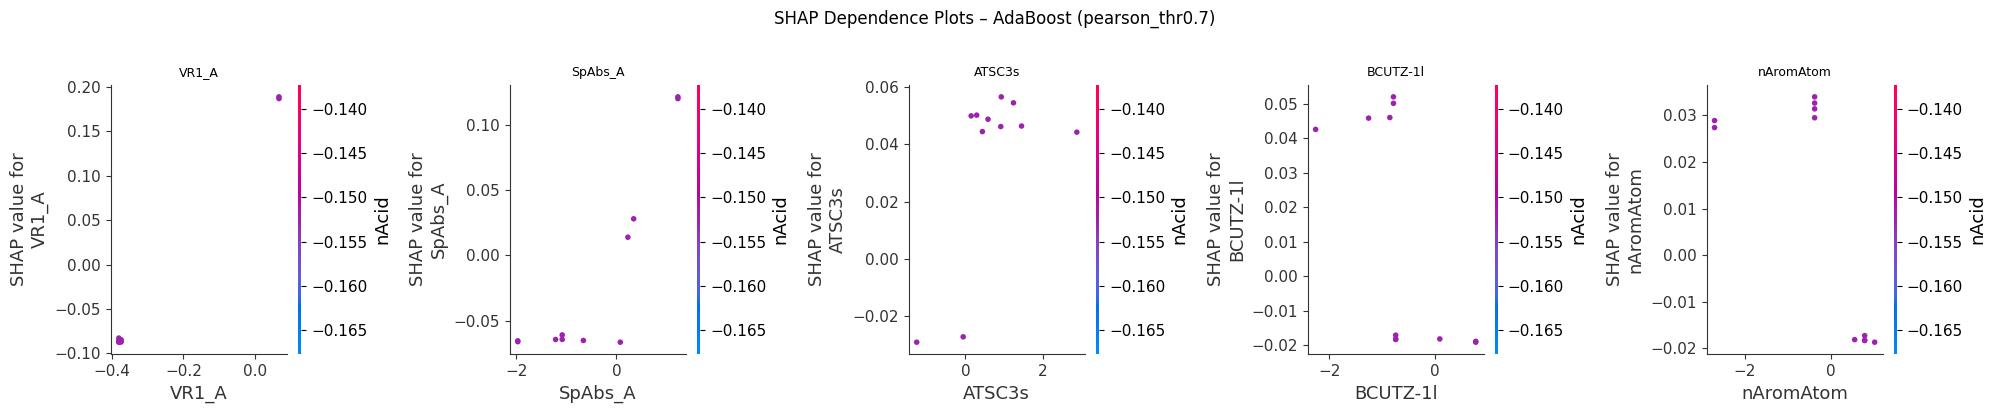

In [10]:
# Tomar el modelo #1 (mejor)
model_name, fs_name = TOP6_MODELS[0][0], TOP6_MODELS[0][1]
key     = f'{model_name}__{fs_name}'
est     = best_estimators[key]
fs_cols = feature_sets[fs_name]
clf_step = est.named_steps['clf']

X_te_transformed = est[:-1].transform(X_test_full[fs_cols])
X_te_df = pd.DataFrame(X_te_transformed, columns=fs_cols)

# Cargar los SHAP values ya calculados (CSV del paso anterior)
shap_df = pd.read_csv(f'{OUTPUT_DIR}/shap_values_1_{model_name}.csv')
sv = shap_df.values

# Top 5 descriptores por importancia SHAP media
top5_descriptors = pd.Series(
    np.abs(sv).mean(axis=0), index=fs_cols
).sort_values(ascending=False).head(5).index.tolist()

print(f'Top 5 descriptores para dependence plots: {top5_descriptors}')

# Dependence plot para cada uno de los top 5
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top5_descriptors):
    shap.dependence_plot(
        feat, sv, X_te_df,
        ax=ax, show=False,
        interaction_index='auto'  # colorea por el descriptor con más interacción
    )
    ax.set_title(feat, fontsize=9)

plt.suptitle(f'SHAP Dependence Plots – {model_name} ({fs_name})',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_dependence_top5_{model_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()

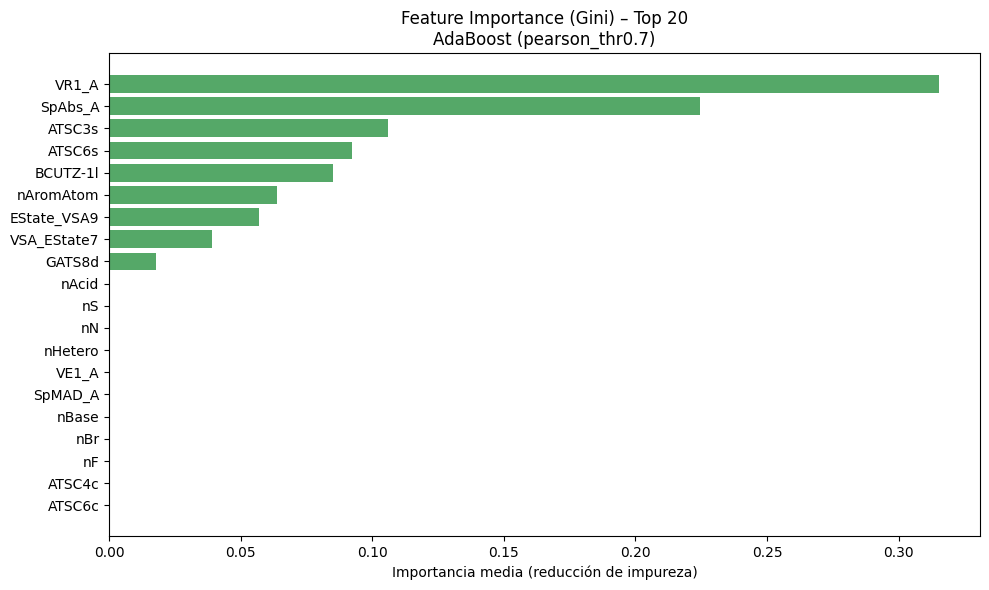

✅ #1 AdaBoost: gini_importance guardado.
#2 LogisticRegression: sin feature_importances_ (no es árbol)


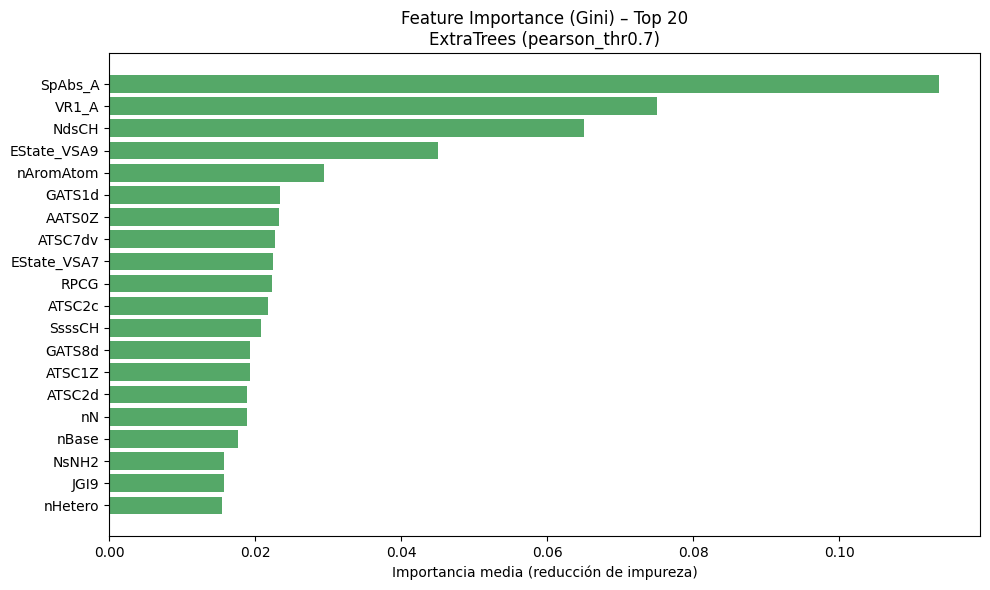

✅ #3 ExtraTrees: gini_importance guardado.


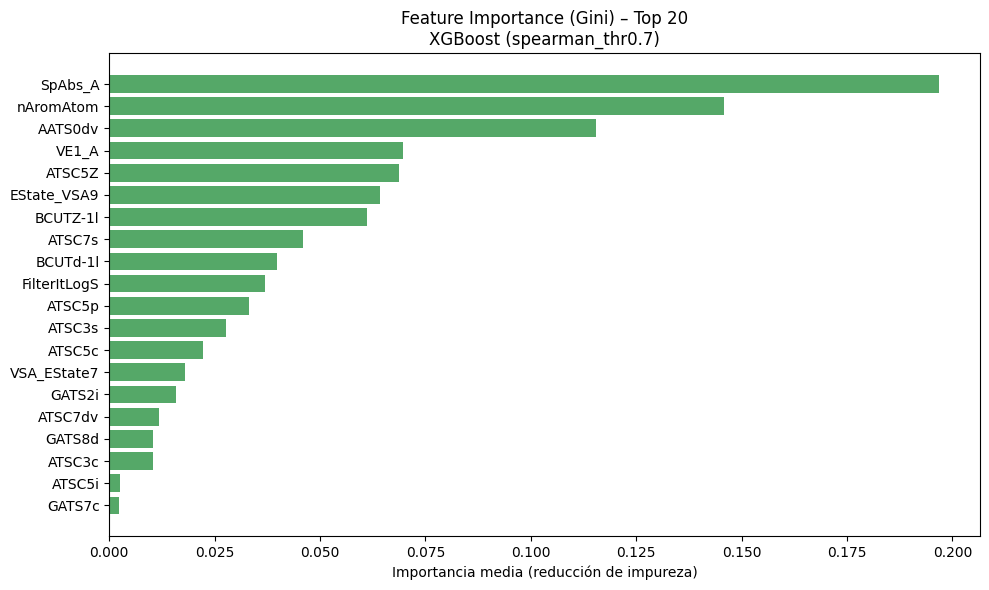

✅ #4 XGBoost: gini_importance guardado.


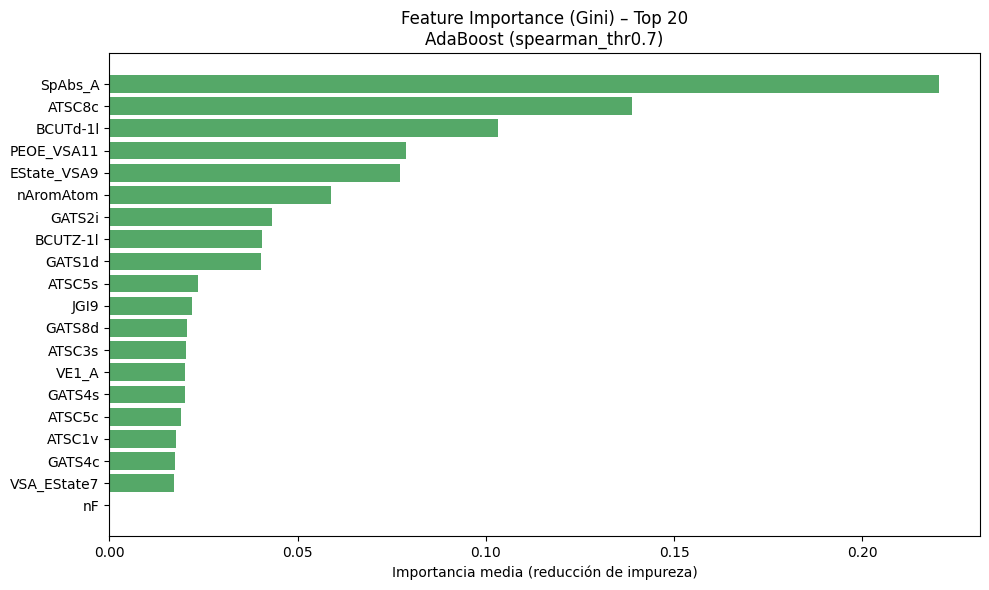

✅ #5 AdaBoost: gini_importance guardado.


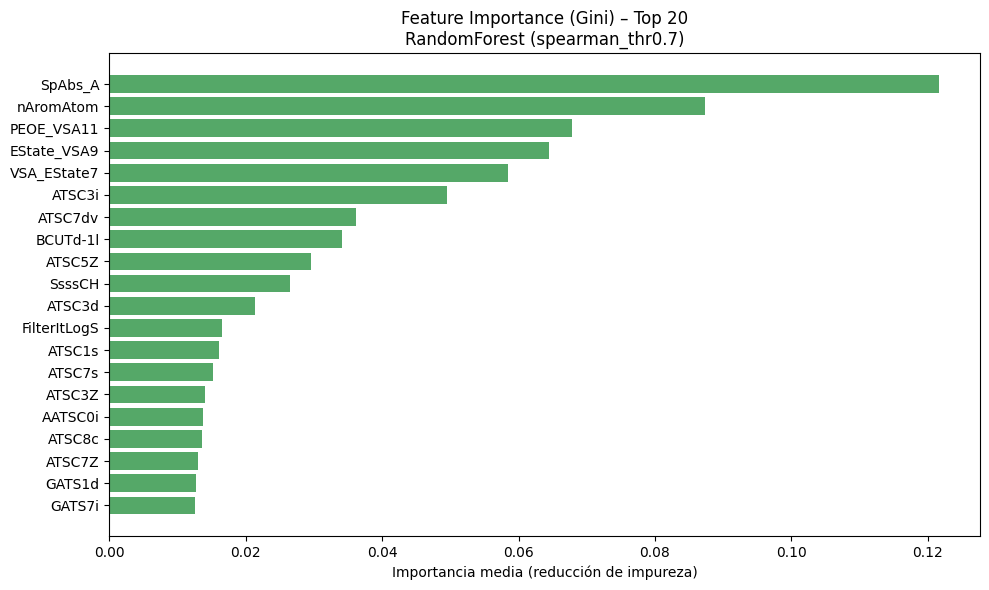

✅ #6 RandomForest: gini_importance guardado.


In [11]:
for rank, (model_name, fs_name, _, _) in enumerate(TOP6_MODELS, start=1):
    key      = f'{model_name}__{fs_name}'
    est      = best_estimators[key]
    clf_step = est.named_steps['clf']
    fs_cols  = feature_sets[fs_name]

    if not hasattr(clf_step, 'feature_importances_'):
        print(f'#{rank} {model_name}: sin feature_importances_ (no es árbol)')
        continue

    fi_df = pd.DataFrame({
        'descriptor': fs_cols,
        'gini_importance': clf_step.feature_importances_
    }).sort_values('gini_importance', ascending=False)

    fi_df.to_csv(f'{OUTPUT_DIR}/gini_importance_{rank}_{model_name}.csv', index=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    top20 = fi_df.head(20)
    ax.barh(top20['descriptor'][::-1], top20['gini_importance'][::-1],
            color='#55A868')
    ax.set_title(f'Feature Importance (Gini) – Top 20\n{model_name} ({fs_name})')
    ax.set_xlabel('Importancia media (reducción de impureza)')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/gini_importance_{rank}_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ #{rank} {model_name}: gini_importance guardado.')

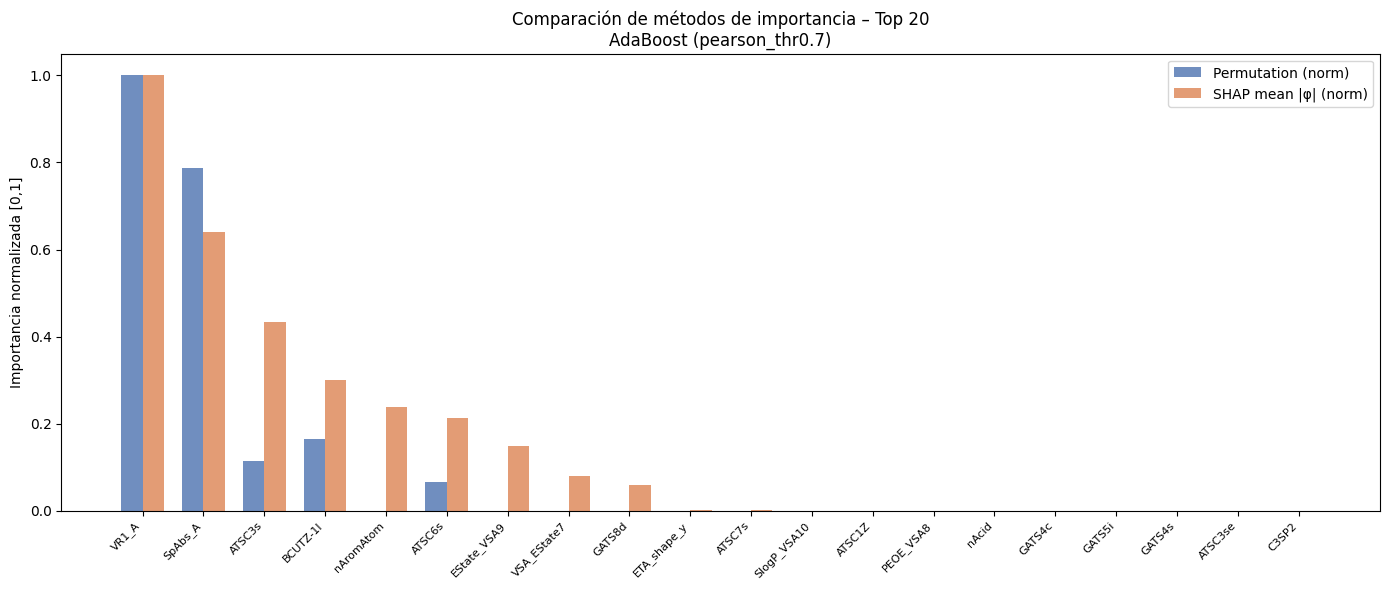

✅ Comparación guardada.


In [12]:
model_name, fs_name = TOP6_MODELS[0][0], TOP6_MODELS[0][1]

# Cargar los tres CSVs
perm_df  = pd.read_csv(f'{OUTPUT_DIR}/permutation_importance_1_{model_name}.csv')
shap_df2 = pd.read_csv(f'{OUTPUT_DIR}/shap_values_1_{model_name}.csv')

shap_mean = pd.DataFrame({
    'descriptor': shap_df2.columns,
    'shap_importance': np.abs(shap_df2.values).mean(axis=0)
})

# Merge de los tres métodos
compare = perm_df.rename(columns={
    'feature': 'descriptor',
    'importance_mean': 'perm_importance'
})[['descriptor', 'perm_importance']].merge(
    shap_mean, on='descriptor', how='inner'
)

# Añadir Gini si el modelo es árbol
gini_path = f'{OUTPUT_DIR}/gini_importance_1_{model_name}.csv'
if os.path.exists(gini_path):
    gini_df = pd.read_csv(gini_path)
    compare = compare.merge(
        gini_df.rename(columns={'gini_importance': 'gini_imp'}),
        on='descriptor', how='left'
    )

# Normalizar entre 0 y 1 para comparación visual
for col in ['perm_importance', 'shap_importance']:
    rng = compare[col].max() - compare[col].min()
    compare[col + '_norm'] = (compare[col] - compare[col].min()) / rng if rng > 0 else 0

compare = compare.sort_values('shap_importance_norm', ascending=False)
compare.to_csv(f'{OUTPUT_DIR}/comparacion_importancias_{model_name}.csv', index=False)

# Gráfico comparativo top 20
top20c = compare.head(20)
x = np.arange(len(top20c))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, top20c['perm_importance_norm'], width,
       label='Permutation (norm)', color='#4C72B0', alpha=0.8)
ax.bar(x + width/2, top20c['shap_importance_norm'], width,
       label='SHAP mean |φ| (norm)', color='#DD8452', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(top20c['descriptor'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importancia normalizada [0,1]')
ax.set_title(f'Comparación de métodos de importancia – Top 20\n{model_name} ({fs_name})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparacion_importancias_{model_name}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparación guardada.')